# Segmentation Visualisation — B0 (frozen SigLIP-B/16)

Companion to `02_b0_benchmark.ipynb`. Visualises what the model is actually predicting:

1. Per-class cosine-similarity heatmaps (which patches fire for which class)
2. Predicted label map vs ground-truth mask
3. Three extraction methods side-by-side (standard / MaskCLIP / SCLIP)
4. Raw-encoder features vs post-layernorm features — compare which is better aligned

In [7]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import os, types, getpass
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

from transformers import SiglipModel, AutoProcessor
import torchvision.datasets as tvd

if not os.environ.get('HF_TOKEN'):
    os.environ['HF_TOKEN'] = getpass.getpass('HF token (read scope): ')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cpu


In [8]:
# ── 2. Load model + VOC ───────────────────────────────────────────────────────
MODEL_ID   = 'google/siglip-base-patch16-384'
EVAL_SIZE  = 384
PATCH_SIZE = 16
N_SIDE     = EVAL_SIZE // PATCH_SIZE   # 24
TEMPLATE   = 'a photo of a {}'

processor = AutoProcessor.from_pretrained(MODEL_ID, token=os.environ['HF_TOKEN'])
model     = SiglipModel.from_pretrained(MODEL_ID, token=os.environ['HF_TOKEN'])
model     = model.to(DEVICE).eval()
print('Model loaded.')

VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor',
]

# Standard VOC colour palette (21 colours: background + 20 fg)
VOC_COLORS = np.array([
    [  0,   0,   0],  # 0  background
    [128,   0,   0],  # 1  aeroplane
    [  0, 128,   0],  # 2  bicycle
    [128, 128,   0],  # 3  bird
    [  0,   0, 128],  # 4  boat
    [128,   0, 128],  # 5  bottle
    [  0, 128, 128],  # 6  bus
    [128, 128, 128],  # 7  car
    [ 64,   0,   0],  # 8  cat
    [192,   0,   0],  # 9  chair
    [ 64, 128,   0],  # 10 cow
    [192, 128,   0],  # 11 diningtable
    [ 64,   0, 128],  # 12 dog
    [192,   0, 128],  # 13 horse
    [ 64, 128, 128],  # 14 motorbike
    [192, 128, 128],  # 15 person
    [  0,  64,   0],  # 16 pottedplant
    [128,  64,   0],  # 17 sheep
    [  0, 192,   0],  # 18 sofa
    [128, 192,   0],  # 19 train
    [  0,  64, 128],  # 20 tvmonitor
], dtype=np.uint8)

VOC_ROOT = Path('/tmp/voc')
voc_val  = tvd.VOCSegmentation(
    root=str(VOC_ROOT), year='2012', image_set='val', download=True
)
print(f'VOC 2012 val: {len(voc_val)} images')

Loading weights: 100%|██████████| 408/408 [00:00<00:00, 21143.05it/s]


Model loaded.
VOC 2012 val: 1449 images


In [9]:
# ── 3. Feature extraction helpers (two variants) ──────────────────────────────
#
# Variant A — raw encoder (before post_layernorm):
#   Uses a forward hook. What we used in 02_b0_benchmark.
#   The raw features were NEVER directly paired with text in SigLIP training
#   (training used mean(patches) → post_layernorm).
#
# Variant B — post_layernorm per-patch:
#   model.vision_model(...).last_hidden_state already has post_layernorm applied.
#   No hook needed. MHAP only goes into pooler_output, not last_hidden_state.
#   Closer to the contrastive space SigLIP was trained in.

def _maskclip_attn_fwd(self, hidden_states, attention_mask=None, **kwargs):
    return self.out_proj(self.v_proj(hidden_states)), None

def _sclip_attn_fwd(self, hidden_states, attention_mask=None, **kwargs):
    B, N, C = hidden_states.shape
    head_dim = C // self.num_heads
    scale    = head_dim ** -0.5
    k = self.k_proj(hidden_states).reshape(B, N, self.num_heads, head_dim).transpose(1, 2)
    v = self.v_proj(hidden_states).reshape(B, N, self.num_heads, head_dim).transpose(1, 2)
    attn = F.softmax((k @ k.transpose(-2, -1)) * scale, dim=-1)
    out  = (attn @ v).transpose(1, 2).reshape(B, N, C)
    return self.out_proj(out), None


def extract_raw(model, pixel_values, method='standard'):
    """Variant A: raw encoder output BEFORE post_layernorm (via hook)."""
    captured = []
    hook = model.vision_model.encoder.register_forward_hook(
        lambda m, inp, out: captured.append(out.last_hidden_state.detach())
    )
    last_attn = model.vision_model.encoder.layers[-1].self_attn
    orig_fwd  = last_attn.forward
    if method == 'maskclip':
        last_attn.forward = types.MethodType(_maskclip_attn_fwd, last_attn)
    elif method == 'sclip':
        last_attn.forward = types.MethodType(_sclip_attn_fwd, last_attn)
    try:
        with torch.no_grad():
            model.vision_model(pixel_values=pixel_values)
        return captured[0]   # (B, N, D)
    finally:
        hook.remove()
        if method != 'standard':
            last_attn.forward = orig_fwd


def extract_postnorm(model, pixel_values, method='standard'):
    """Variant B: per-patch features AFTER post_layernorm (no hook needed)."""
    last_attn = model.vision_model.encoder.layers[-1].self_attn
    orig_fwd  = last_attn.forward
    if method == 'maskclip':
        last_attn.forward = types.MethodType(_maskclip_attn_fwd, last_attn)
    elif method == 'sclip':
        last_attn.forward = types.MethodType(_sclip_attn_fwd, last_attn)
    try:
        with torch.no_grad():
            out = model.vision_model(pixel_values=pixel_values)
        return out.last_hidden_state.detach()   # (B, N, D), post_layernorm applied
    finally:
        if method != 'standard':
            last_attn.forward = orig_fwd


def encode_text(model, processor, class_names, device):
    """Text EOS features (after final_layer_norm, before untrained linear head)."""
    prompts = [TEMPLATE.format(c) for c in class_names]
    inputs  = processor(text=prompts, return_tensors='pt', padding=True).to(device)
    with torch.no_grad():
        feats = model.text_model(**inputs).last_hidden_state[:, -1, :]
    return F.normalize(feats, dim=-1)   # (n_cls, D)


print('Helpers defined: extract_raw, extract_postnorm, encode_text')

Helpers defined: extract_raw, extract_postnorm, encode_text


In [10]:
# ── 4. Pick diverse images ────────────────────────────────────────────────────
# Hand-pick indices that each contain a single dominant foreground class
# so the visualisations are easy to interpret.

def find_images_with_class(voc, class_idx, n=3, skip=0):
    """Return the first n indices where class_idx is in the GT mask."""
    found, checked = [], 0
    for i in range(len(voc)):
        gt = np.array(voc[i][1])
        if class_idx in np.unique(gt):
            if checked >= skip:
                found.append(i)
            checked += 1
            if len(found) == n:
                break
    return found

# Pick one image per class for a diverse sample
SHOW = {
    'aeroplane':  find_images_with_class(voc_val, 1,  n=1)[0],
    'cat':        find_images_with_class(voc_val, 8,  n=1)[0],
    'person':     find_images_with_class(voc_val, 15, n=1)[0],
    'horse':      find_images_with_class(voc_val, 13, n=1)[0],
    'dog':        find_images_with_class(voc_val, 12, n=1)[0],
    'bus':        find_images_with_class(voc_val, 6,  n=1)[0],
}
print('Image indices:', SHOW)

Image indices: {'aeroplane': 0, 'cat': 59, 'person': 4, 'horse': 8, 'dog': 34, 'bus': 19}


In [11]:
# ── 5. Utility: label map → RGB ───────────────────────────────────────────────

def label_to_rgb(label_map, colors=VOC_COLORS, void_val=255):
    """Convert (H, W) int label map to (H, W, 3) RGB using VOC_COLORS."""
    h, w = label_map.shape
    rgb  = np.zeros((h, w, 3), dtype=np.uint8)
    for c, col in enumerate(colors):
        rgb[label_map == c] = col
    rgb[label_map == void_val] = [224, 224, 192]   # void → light yellow
    return rgb


def sim_to_pred(patch_feats_n, text_feats, orig_size, tau_seg, n_fg):
    """
    patch_feats_n : (N, D) L2-normalised patch features
    text_feats    : (n_fg, D) L2-normalised text features
    Returns pred  : (H, W) int64 numpy — 0=bg, 1..n_fg
            sim   : (H, W, n_fg) float numpy — per-class similarity maps
    """
    orig_h, orig_w = orig_size
    sim = patch_feats_n @ text_feats.T                       # (N, n_fg)
    n_side = int(sim.shape[0] ** 0.5)
    sim_hw = sim.reshape(n_side, n_side, n_fg)
    sim_t  = sim_hw.permute(2, 0, 1).unsqueeze(0).float()   # (1, n_fg, n, n)
    sim_up = F.interpolate(sim_t, size=(orig_h, orig_w),
                           mode='bilinear', align_corners=False)
    sim_up = sim_up.squeeze(0).permute(1, 2, 0)              # (H, W, n_fg)

    max_sim, pred = sim_up.max(dim=-1)
    pred = pred + 1
    pred[max_sim < tau_seg] = 0
    return pred.cpu().numpy().astype(np.int64), sim_up.cpu().numpy()


print('Utility functions defined.')

Utility functions defined.


In [12]:
# ── 6. Raw vs post-layernorm: cosine-sim range comparison ────────────────────
# For one image, compare the similarity range and top-class ranking
# between the two feature variants.

pil_aero, gt_aero = voc_val[SHOW['aeroplane']]
pix = processor(images=pil_aero, return_tensors='pt').pixel_values.to(DEVICE)
text_feats = encode_text(model, processor, VOC_CLASSES, DEVICE)   # (20, D)

raw_patches  = extract_raw(model, pix, 'standard')                # (1, 576, D)
post_patches = extract_postnorm(model, pix, 'standard')           # (1, 576, D)

raw_n  = F.normalize(raw_patches[0],  dim=-1)   # (576, D)
post_n = F.normalize(post_patches[0], dim=-1)   # (576, D)

sim_raw  = raw_n  @ text_feats.T    # (576, 20)
sim_post = post_n @ text_feats.T

print('=== Aeroplane image: cosine-sim ranges ===')
print(f'  raw encoder   : [{sim_raw.min():.4f}, {sim_raw.max():.4f}]  '
      f'mean={sim_raw.mean():.4f}  std={sim_raw.std():.4f}')
print(f'  post_layernorm: [{sim_post.min():.4f}, {sim_post.max():.4f}]  '
      f'mean={sim_post.mean():.4f}  std={sim_post.std():.4f}')

print()
for feat_name in ['raw encoder', 'post_layernorm']:
    patch_n = raw_n if feat_name == 'raw encoder' else post_n
    g = F.normalize(patch_n.mean(0, keepdim=True), dim=-1) @ text_feats.T
    top3 = g[0].topk(3)
    top3_str = ', '.join(
        f'{VOC_CLASSES[i]}({v:.3f})'
        for v, i in zip(top3.values.tolist(), top3.indices.tolist())
    )
    print(f'  {feat_name:16s} — global top-3: {top3_str}')

=== Aeroplane image: cosine-sim ranges ===
  raw encoder   : [-0.0989, 0.1106]  mean=0.0104  std=0.0334
  post_layernorm: [-0.1020, 0.1179]  mean=0.0053  std=0.0318

  raw encoder      — global top-3: aeroplane(0.041), pottedplant(0.040), chair(0.037)
  post_layernorm   — global top-3: sofa(0.029), tvmonitor(0.024), aeroplane(0.023)


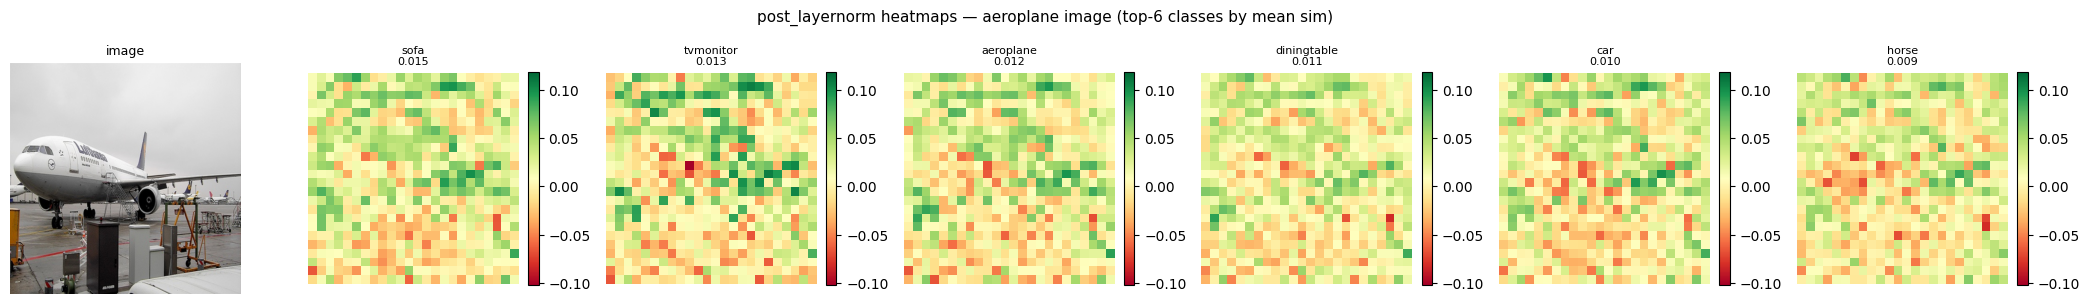

In [13]:
# ── 7. Per-class similarity heatmaps ─────────────────────────────────────────
# For one image, show the cosine similarity of each patch to each VOC class
# as a heatmap overlaid on the image. Uses post_layernorm features.
# Shows only the top-6 ranked classes (by mean sim).

TAU_VIZ = 0.0   # threshold used for heatmap display (adjust after seeing cell-6)

def show_class_heatmaps(pil_img, sim_hw, class_names, title='', n_show=6):
    """
    sim_hw : (n_side, n_side, n_cls) float tensor — patch × class similarities
    Shows n_show classes sorted by mean patch similarity.
    """
    n_cls   = sim_hw.shape[-1]
    mean_s  = sim_hw.reshape(-1, n_cls).mean(0)   # (n_cls,)
    top_idx = mean_s.topk(n_show).indices.tolist()

    n_cols  = n_show
    fig, axes = plt.subplots(1, n_cols + 1, figsize=(3 * (n_cols + 1), 3.2))
    fig.suptitle(title, fontsize=11)

    axes[0].imshow(pil_img.resize((384, 384)))
    axes[0].set_title('image', fontsize=9)
    axes[0].axis('off')

    n_side = sim_hw.shape[0]
    vmin   = float(sim_hw.min())
    vmax   = float(sim_hw.max())

    for col, cls_idx in enumerate(top_idx):
        ax  = axes[col + 1]
        hm  = sim_hw[:, :, cls_idx].numpy()
        im  = ax.imshow(hm, cmap='RdYlGn', vmin=vmin, vmax=vmax,
                        interpolation='nearest')
        ax.set_title(f'{class_names[cls_idx]}\n{mean_s[cls_idx]:.3f}', fontsize=8)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# Show for aeroplane image
post_n_aero = F.normalize(post_patches[0], dim=-1)
sim_aero    = (post_n_aero @ text_feats.T).reshape(N_SIDE, N_SIDE, len(VOC_CLASSES))
show_class_heatmaps(pil_aero, sim_aero, VOC_CLASSES,
                    title='post_layernorm heatmaps — aeroplane image (top-6 classes by mean sim)')

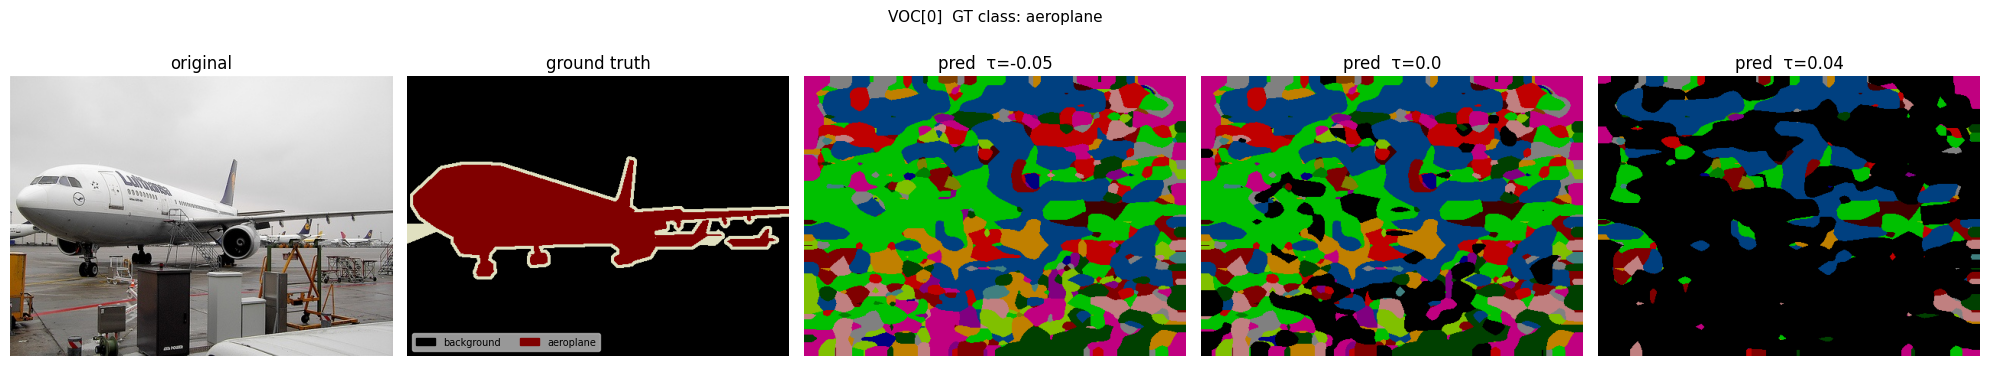

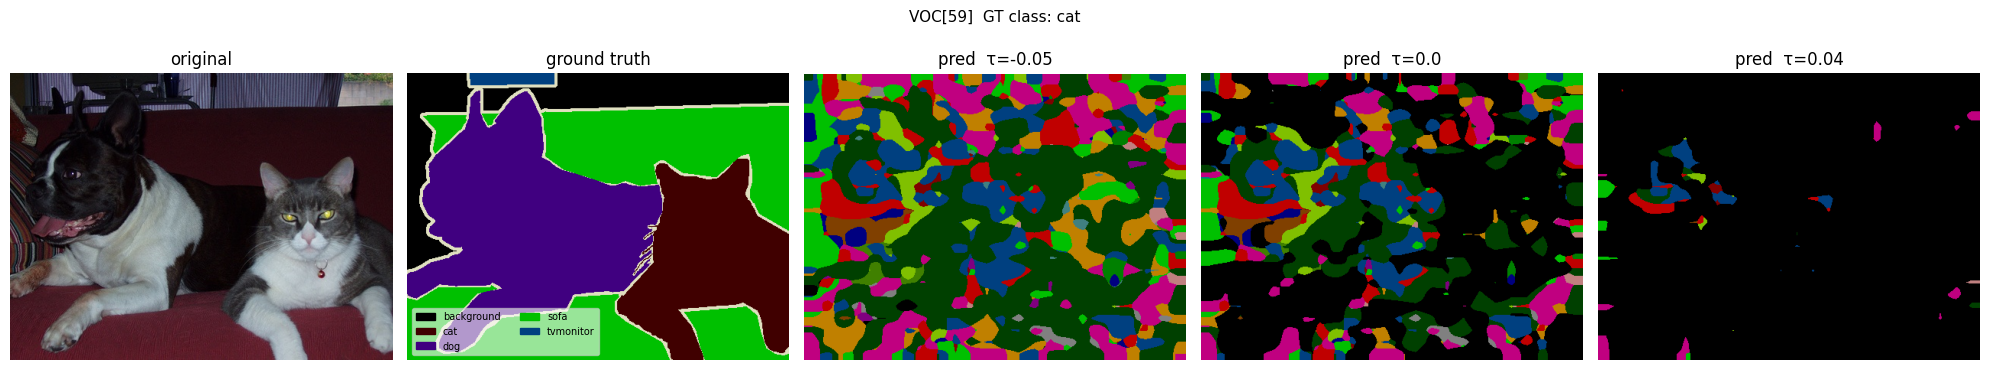

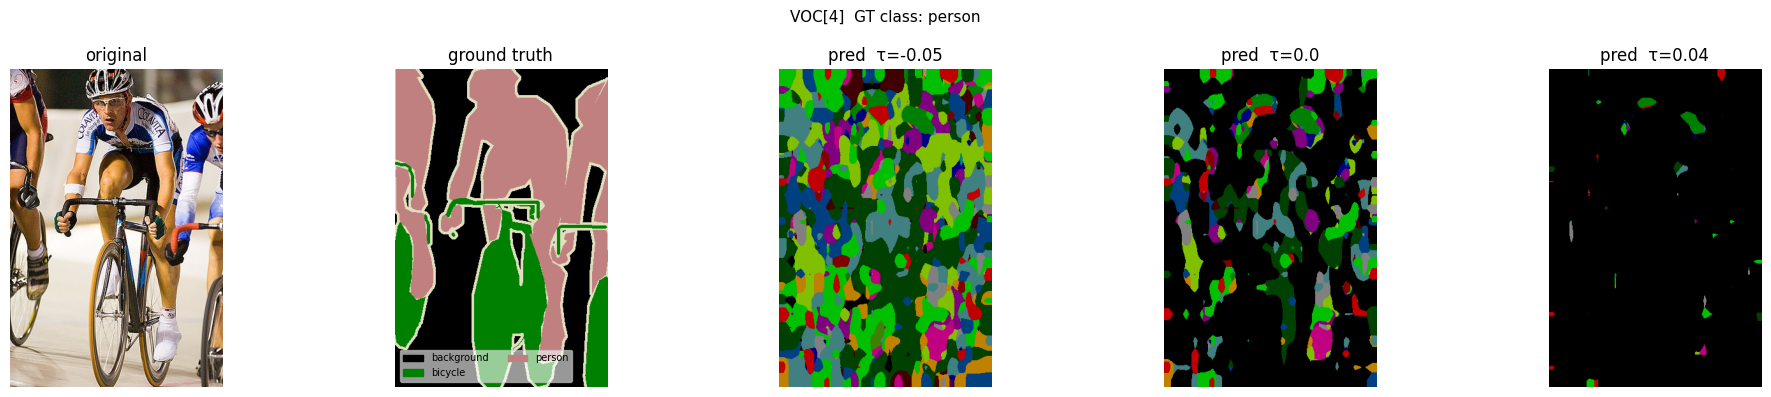

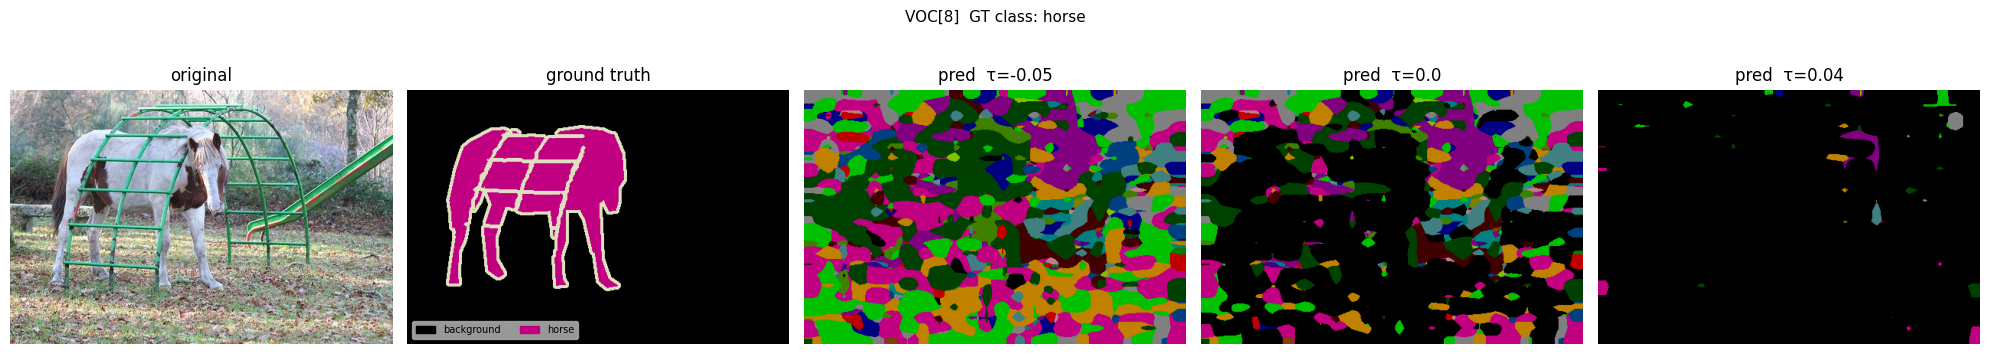

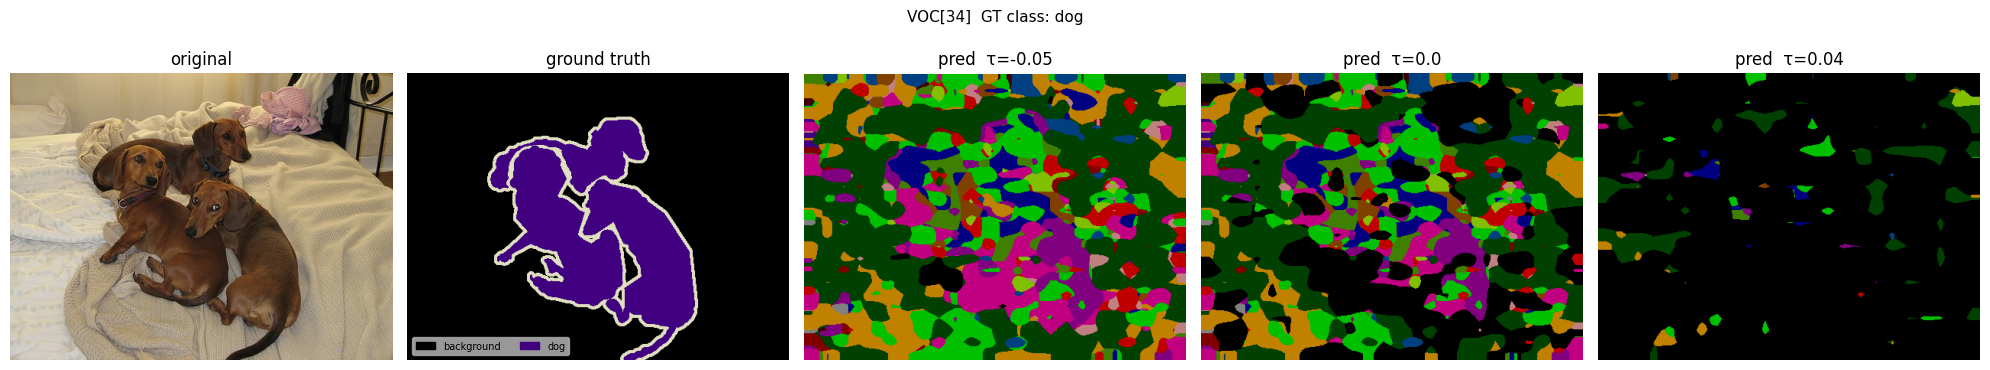

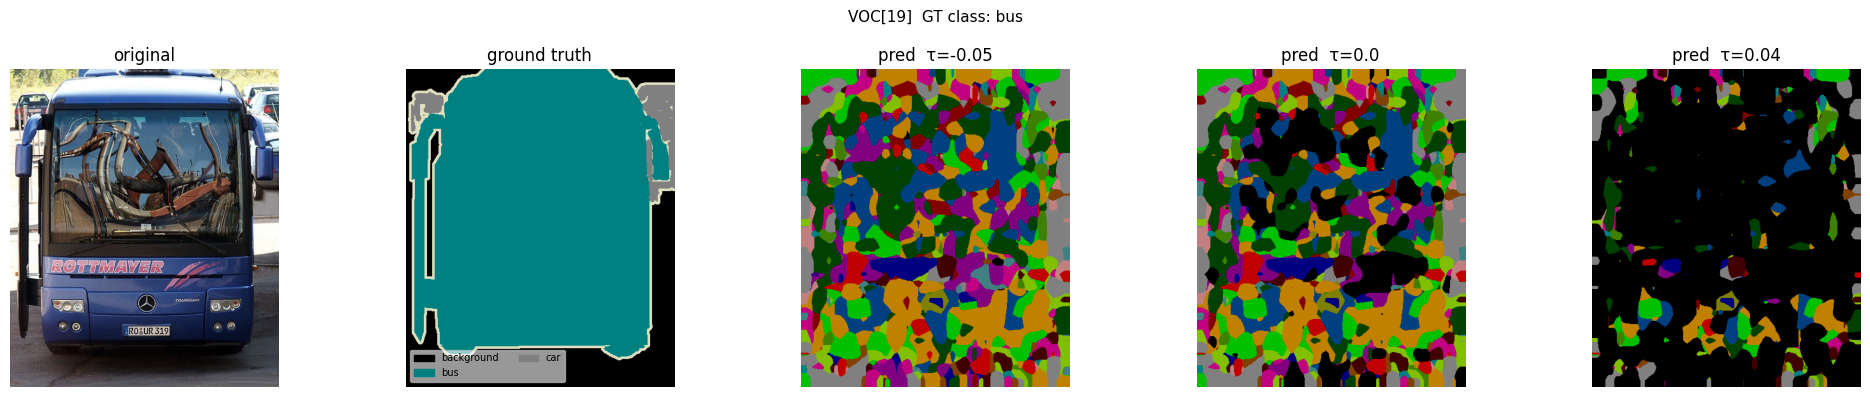

In [14]:
# ── 8. GT vs predicted segmentation (post_layernorm, 3 tau values) ────────────
# For each selected image, show:
#   [original] [GT mask] [pred tau=low] [pred tau=mid] [pred tau=high]

TAU_LOW  = -0.05
TAU_MID  =  0.0
TAU_HIGH =  0.04

def visualise_gt_vs_pred(pil_img, gt_mask, patches_n, text_feats, class_name, idx):
    orig_w, orig_h = pil_img.size
    gt_arr = np.array(gt_mask)
    gt_rgb = label_to_rgb(gt_arr)

    n_fg = len(VOC_CLASSES)
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f'VOC[{idx}]  GT class: {class_name}', fontsize=11)

    axes[0].imshow(pil_img)
    axes[0].set_title('original')
    axes[0].axis('off')

    axes[1].imshow(gt_rgb)
    axes[1].set_title('ground truth')
    axes[1].axis('off')

    for ax, tau in zip(axes[2:], [TAU_LOW, TAU_MID, TAU_HIGH]):
        pred, _ = sim_to_pred(patches_n, text_feats, (orig_h, orig_w), tau, n_fg)
        pred_rgb = label_to_rgb(pred)
        ax.imshow(pred_rgb)
        ax.set_title(f'pred  τ={tau}')
        ax.axis('off')

    # Legend for classes present in GT
    present = [c for c in np.unique(gt_arr) if c < len(VOC_COLORS)]
    patches = [
        mpatches.Patch(color=VOC_COLORS[c] / 255,
                       label=('background' if c == 0 else VOC_CLASSES[c - 1]))
        for c in present
    ]
    axes[1].legend(handles=patches, loc='lower left', fontsize=7,
                   framealpha=0.6, ncol=2)
    plt.tight_layout()
    plt.show()


for cls_name, img_idx in SHOW.items():
    pil_img, gt_mask = voc_val[img_idx]
    pix = processor(images=pil_img, return_tensors='pt').pixel_values.to(DEVICE)
    feats = extract_postnorm(model, pix, 'standard')
    patches_n = F.normalize(feats[0], dim=-1)
    visualise_gt_vs_pred(pil_img, gt_mask, patches_n, text_feats, cls_name, img_idx)

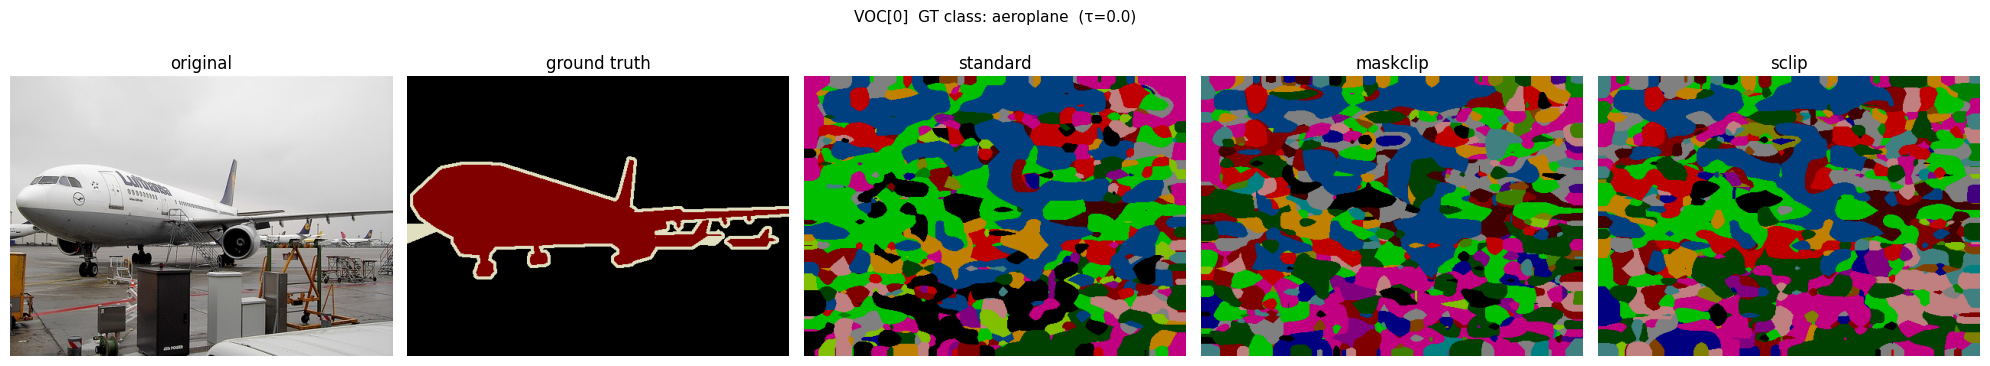

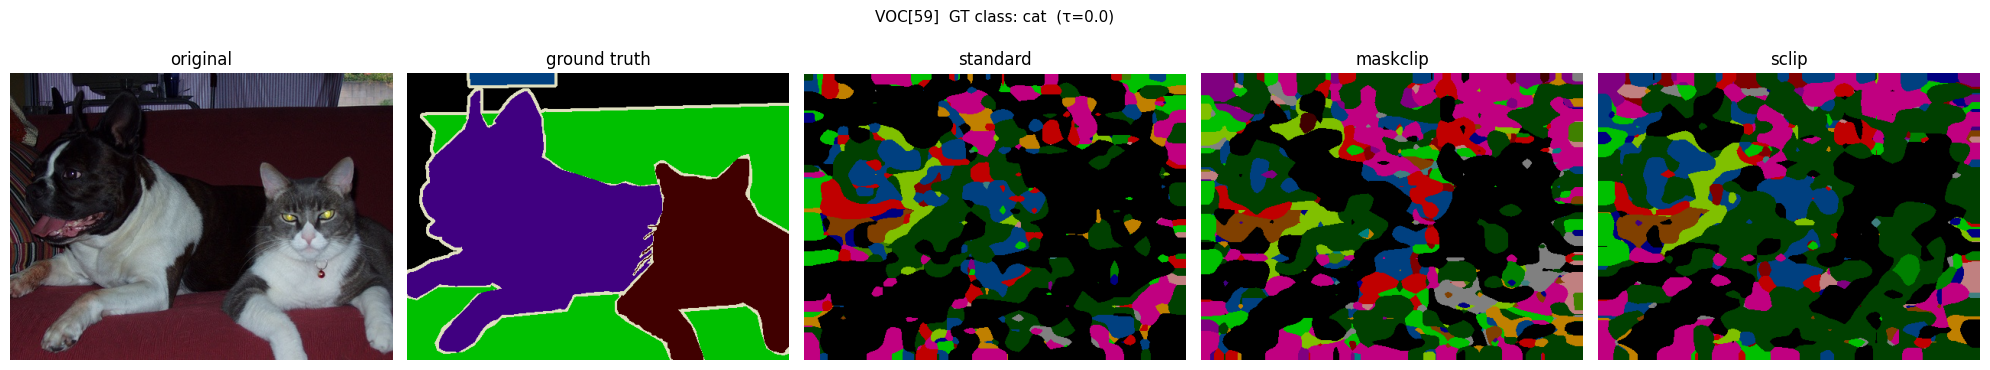

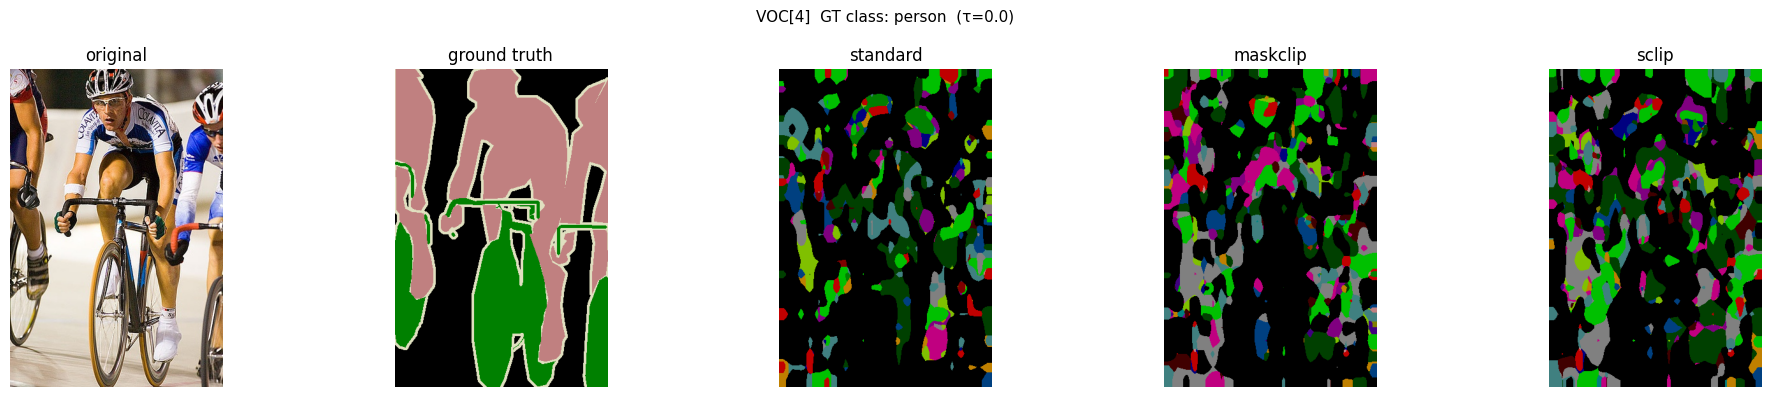

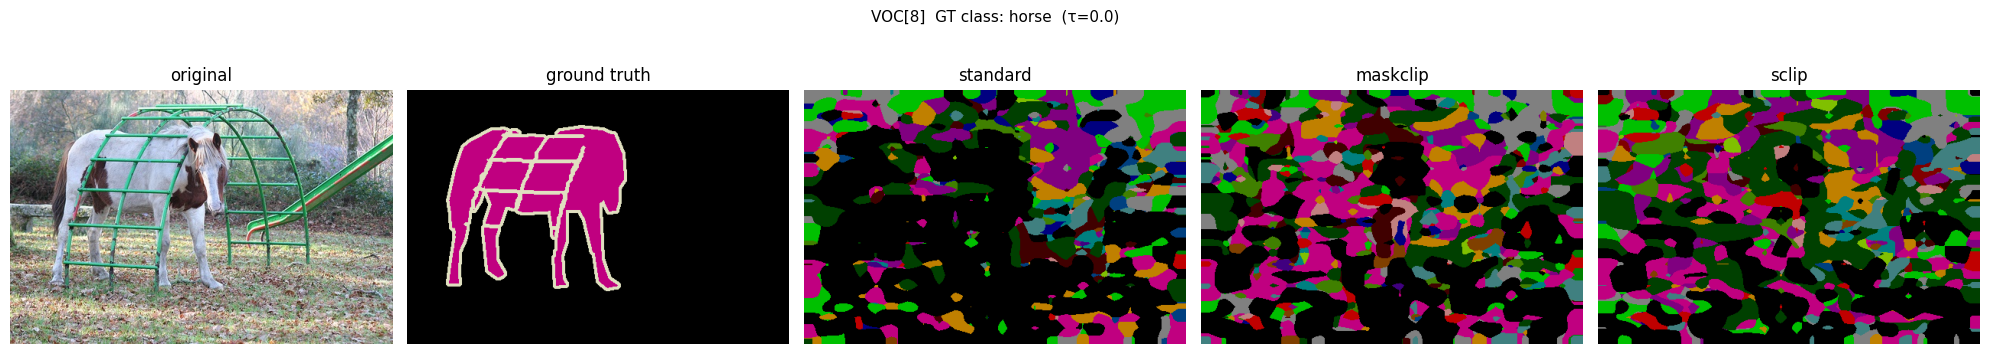

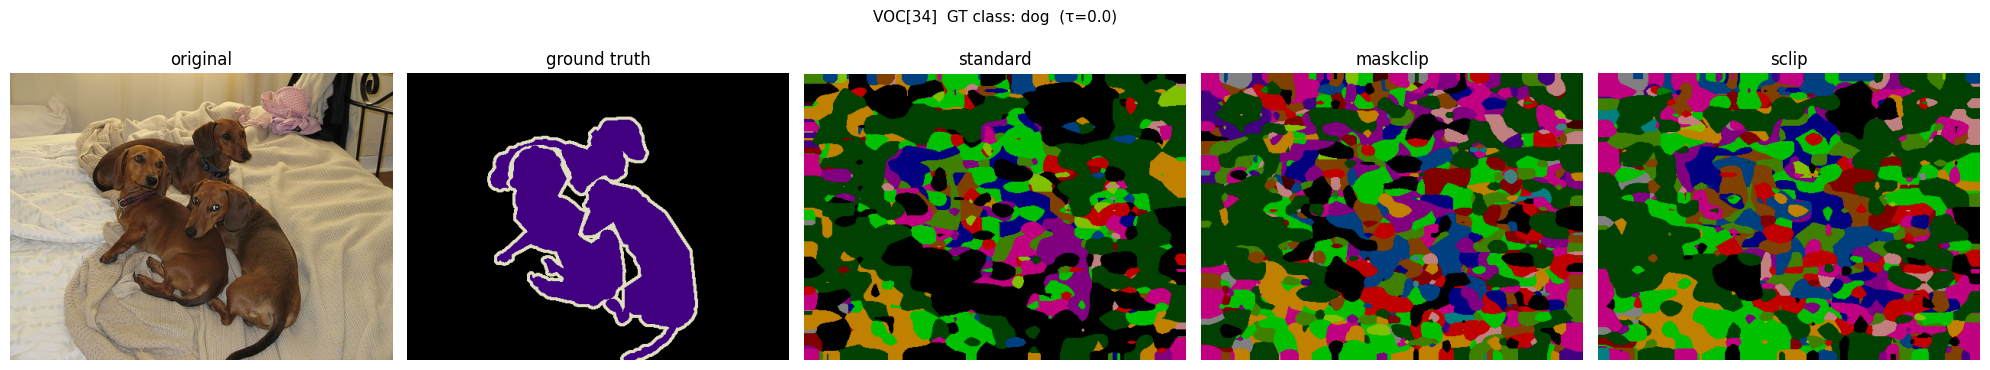

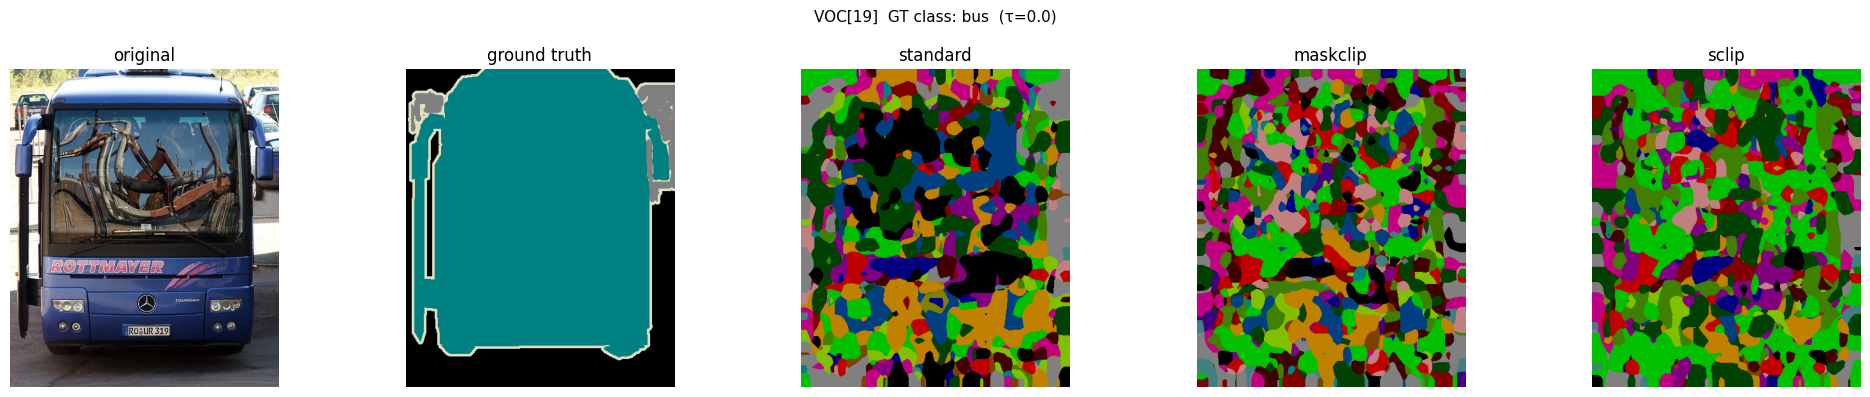

In [15]:
# ── 9. Three methods side-by-side ─────────────────────────────────────────────
# For each selected image, compare standard / MaskCLIP / SCLIP predictions
# at the same tau (TAU_MID = 0.0).
# Using post_layernorm features for all three.

def compare_methods(pil_img, gt_mask, text_feats, cls_name, idx, tau=TAU_MID):
    orig_w, orig_h = pil_img.size
    gt_arr = np.array(gt_mask)
    n_fg   = len(VOC_CLASSES)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f'VOC[{idx}]  GT class: {cls_name}  (τ={tau})', fontsize=11)

    axes[0].imshow(pil_img)
    axes[0].set_title('original')
    axes[0].axis('off')

    axes[1].imshow(label_to_rgb(np.array(gt_mask)))
    axes[1].set_title('ground truth')
    axes[1].axis('off')

    pix = processor(images=pil_img, return_tensors='pt').pixel_values.to(DEVICE)

    for ax, method in zip(axes[2:], ['standard', 'maskclip', 'sclip']):
        feats     = extract_postnorm(model, pix, method)
        patches_n = F.normalize(feats[0], dim=-1)
        pred, _   = sim_to_pred(patches_n, text_feats, (orig_h, orig_w), tau, n_fg)
        ax.imshow(label_to_rgb(pred))
        ax.set_title(method)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


for cls_name, img_idx in SHOW.items():
    pil_img, gt_mask = voc_val[img_idx]
    compare_methods(pil_img, gt_mask, text_feats, cls_name, img_idx)

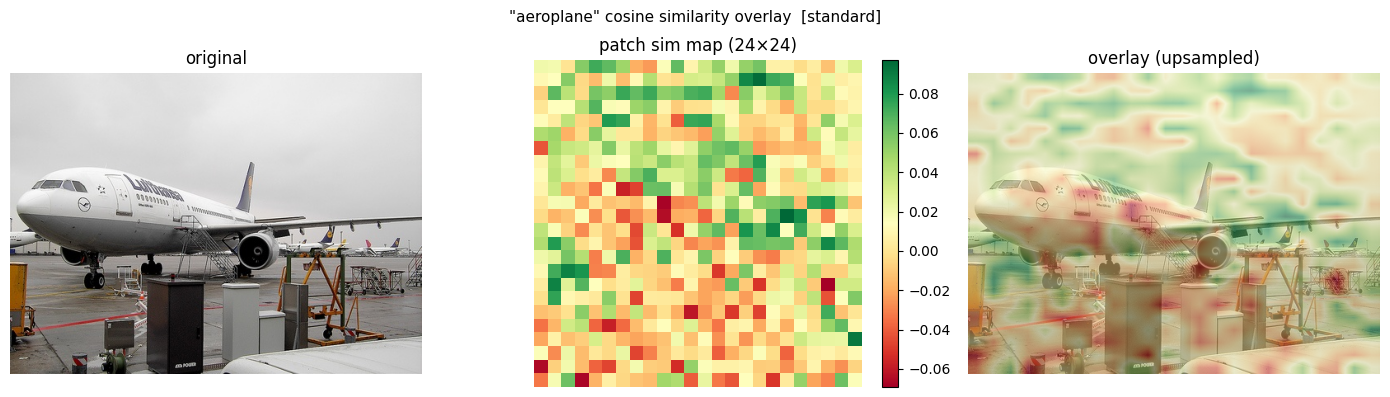

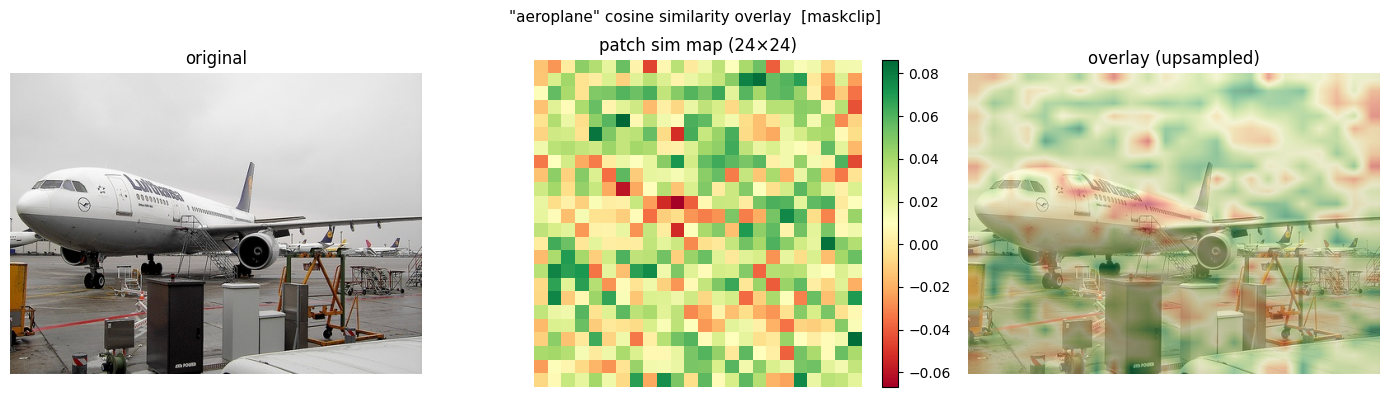

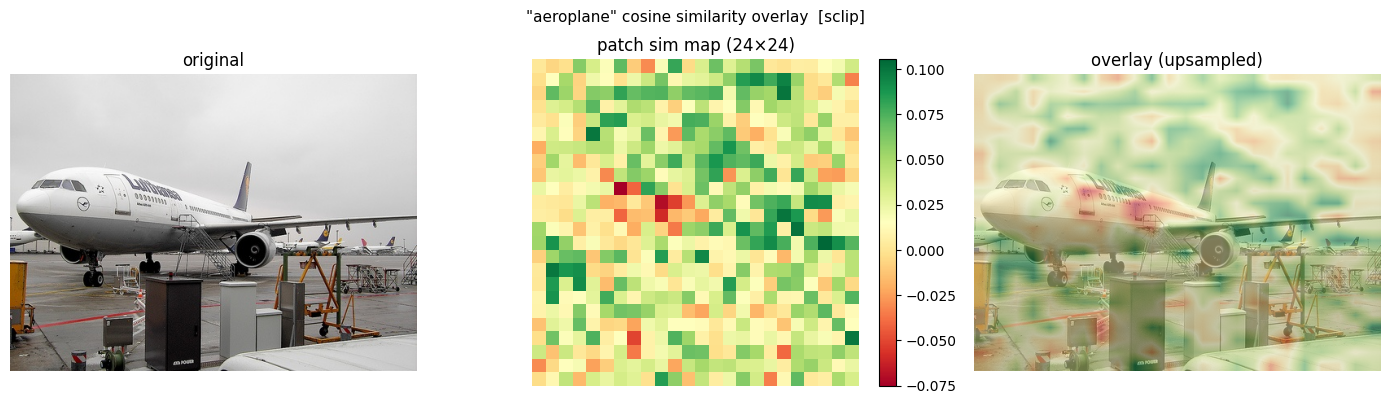

In [16]:
# ── 10. Aeroplane-class similarity overlay (spatial) ─────────────────────────
# For the aeroplane image, show the raw patch similarity to 'aeroplane'
# overlaid transparently on the original image.
# Makes it easy to see whether the model's activation concentrates on the plane.

def sim_overlay(pil_img, patches_n, text_feats, class_idx, title=''):
    orig_w, orig_h = pil_img.size

    sim = (patches_n @ text_feats.T)[:, class_idx]   # (N,)
    sim_hw = sim.reshape(N_SIDE, N_SIDE).float().numpy()

    # Upsample to original resolution
    sim_up = F.interpolate(
        torch.from_numpy(sim_hw).unsqueeze(0).unsqueeze(0),
        size=(orig_h, orig_w), mode='bilinear', align_corners=False
    ).squeeze().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(title, fontsize=11)

    axes[0].imshow(pil_img)
    axes[0].set_title('original')
    axes[0].axis('off')

    im = axes[1].imshow(sim_hw, cmap='RdYlGn', interpolation='nearest')
    axes[1].set_title(f'patch sim map ({N_SIDE}×{N_SIDE})')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    axes[2].imshow(pil_img)
    axes[2].imshow(sim_up, cmap='RdYlGn', alpha=0.5)
    axes[2].set_title('overlay (upsampled)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


for method in ['standard', 'maskclip', 'sclip']:
    pil_aero, _ = voc_val[SHOW['aeroplane']]
    pix          = processor(images=pil_aero, return_tensors='pt').pixel_values.to(DEVICE)
    feats        = extract_postnorm(model, pix, method)
    patches_n    = F.normalize(feats[0], dim=-1)
    aero_idx     = VOC_CLASSES.index('aeroplane')   # 0
    sim_overlay(pil_aero, patches_n, text_feats, aero_idx,
                title=f'"aeroplane" cosine similarity overlay  [{method}]')